In [1]:
from rltesting.torch_rl.buffers import ReplayBuffer
from dreamer import *
import gymnasium as gym
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from utils import WeightedAverageOverBins

import ale_py
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from rltesting.torch_rl.buffers import PerEnvBuffer
import argparse

parser = argparse.ArgumentParser(description="just a temporary argparse while I debug the world model, will be moved elsewhere later")
# specified for Atari specifically by default and using the 200M size model for Dreamer
parser.add_argument("--obs_type", default="image", choices=["image", "vector", "multi"]) # need to handle multi for some robotics environments/experiments
encoder_parser = parser.add_argument_group("encoder")
vector_parser = parser.add_argument_group("vector")
world_model_parser = parser.add_argument_group("world_model")
encoder_parser.add_argument("--num_channels", default=3, type=int)
encoder_parser.add_argument("--image_size", default=64, type=int) # images should be square
encoder_parser.add_argument("--kernel_size", default=4, type=int) # best to keep it 4 or 6
encoder_parser.add_argument("--filter_base", default=64, type=int) # the base number of filters, which is doubled for each convolutional layer
encoder_parser.add_argument("--num_convs", default=4, type=int) # total number of convolutions, after which the dimension is size / 2^num_convs, and the final number of filters is filter_base * 2^(num_convs-1)
vector_parser.add_argument("--obs_dim", default=None, type=int) # specify both this and image stuff for multi
world_model_parser.add_argument("--hidden_dim", default=1024, type=int) # hidden dims of MLPs
world_model_parser.add_argument("--hidden_state_size", default=8192, type=int) # hidden state of GRU/RSSM
world_model_parser.add_argument("--num_hiddens_world_model", default=1, type=int) # determines the depth for MLPs in the world model
world_model_parser.add_argument("--num_hiddens_actor_critic", default=2, type=int)
world_model_parser.add_argument("--action_dim", default=18, type=int)
world_model_parser.add_argument("--action_type", default="discrete", choices=["discrete", "continuous"])
world_model_parser.add_argument("--num_categoricals", default=32, type=int) # the number of rows in the latent
world_model_parser.add_argument("--num_codes", default=64, type=int) # the actual dim that's softmaxed over in the latent
world_model_parser.add_argument("--latent_unimix", default=0.01, type=float)
world_model_parser.add_argument("--use_block_linear", default=True, type=bool)
world_model_parser.add_argument("--act", default="silu", choices=["silu", "gelu", "relu"])
world_model_parser.add_argument("--prediction_loss_coef", default=1, type=float)
world_model_parser.add_argument("--dynamics_loss_coef", default=1, type=float)
world_model_parser.add_argument("--representation_loss_coef", default=0.1, type=float)
world_model_parser.add_argument("--free_nats", default=1, type=float)
world_model_parser.add_argument("--bin_low", default=-20, type=int)
world_model_parser.add_argument("--bin_high", default=20, type=int)
world_model_parser.add_argument("--num_bins", default=255, type=int)
parser.add_argument("--sample_batch_size", default=16, type=int)
parser.add_argument("--sample_seq_len", default=64, type=int)
parser.add_argument("--imagination_batch_size", default=512, type=int)
parser.add_argument("--rollout_length", default=16, type=int)
parser.add_argument("--num_envs", default=16, type=int)
parser.add_argument("--critic_tau", default=0.02, type=float)
parser.add_argument("--critic_imagination_loss_coef", default=1, type=float)
parser.add_argument("--critic_replay_loss_coef", default=0.3, type=float)
parser.add_argument("--entropy_coef", default=3e-4, type=float)
parser.add_argument("--return_range_tau", default=0.01, type=int)
parser.add_argument("--gamma", default=0.997, type=float)
parser.add_argument("--lambda_", default=0.95, type=float)
parser.add_argument("--percentiles", default=0.05, type=float)
parser.add_argument("--device", default="cuda" if torch.cuda.is_available() else "cpu")
config = parser.parse_args(args=[])
if config.act == "silu":
    config.act = nn.SiLU
elif config.act == "gelu":
    config.act = nn.GELU
elif config.act == "relu":
    config.act = nn.ReLU
if config.obs_type == "image":
    config.image_dim = (config.num_channels, config.image_size, config.image_size)
    size = config.image_size // 2 ** (config.num_convs)
    config.output_dim = (config.filter_base * 2 ** (config.num_convs - 1), size, size)
config.latent_size = config.num_categoricals * config.num_codes
config.state_size = config.hidden_state_size + config.latent_size

def make_env(gym_id):
    def thunk():
        gym.register_envs(ale_py)
        env = gym.make(gym_id, render_mode="rgb_array", full_action_space=True)
        env = gym.wrappers.ResizeObservation(env, (64, 64))
        env = gym.wrappers.TransformObservation(env, lambda x: x.transpose(2, 0, 1), observation_space=gym.spaces.Box(0, 255, config.image_dim))
        return env
    return thunk

num_envs = config.num_envs
env = make_vec_env(make_env('ALE/Pong-v5'), num_envs, vec_env_cls=SubprocVecEnv, vec_env_kwargs=dict(start_method='spawn'))
dreamer = DreamerV3(config)

A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (vers

In [2]:
obs = env.reset()
for i in range(100):
    if i % 100 == 0:
        print(i)
    action, latent = dreamer.choose_action(torch.tensor(obs).float().to(config.device))
    next_obs, reward, done, info = env.step(action)
    dreamer.process_sample(obs, latent, action, reward, done)
    obs = next_obs

0


In [3]:
losses_wm = []
losses_actor = []
losses_critic = []
losses_dict = []
for i in range(1000):
    if i % 100 == 0:
        print(i)
    action, latent = dreamer.choose_action(torch.tensor(obs).float().to(config.device))
    next_obs, reward, done, info = env.step(action)
    dreamer.process_sample(obs, latent, action, reward, done)
    obs = next_obs
    loss_wm, loss_actor, loss_critic, loss_dict = dreamer.train()
    losses_wm.append(loss_wm)
    losses_actor.append(loss_actor)
    losses_critic.append(loss_critic)
    losses_dict.append(loss_dict)

0
100
200
300
400


ValueError: Expected parameter logits (Tensor of shape (16, 18)) of distribution Categorical(logits: torch.Size([16, 18])) to satisfy the constraint IndependentConstraint(Real(), 1), but found invalid values:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

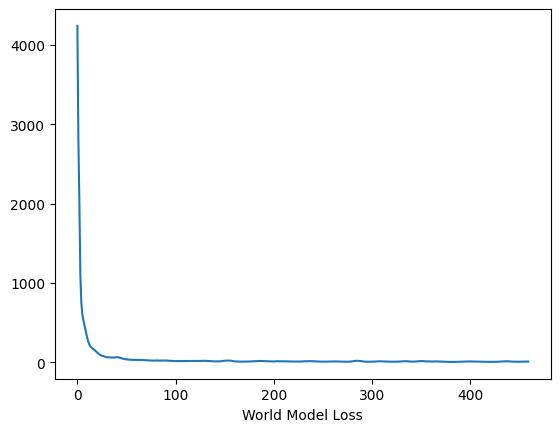

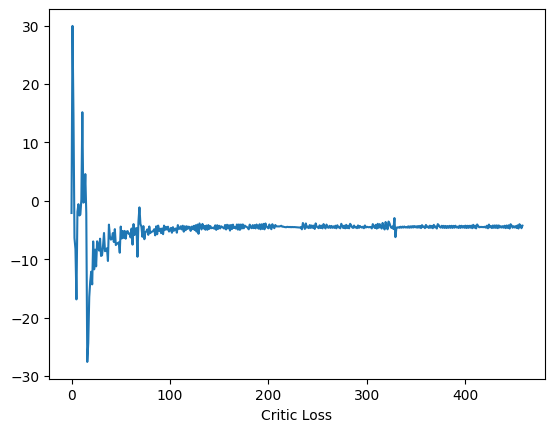

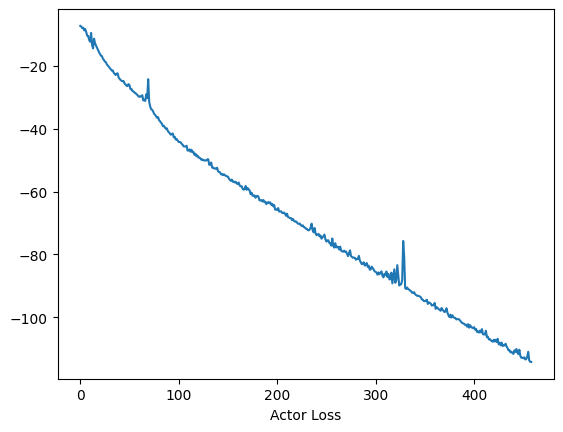

In [4]:
plt.plot(losses_wm)
plt.xlabel("World Model Loss")
plt.show()
plt.plot(losses_critic)
plt.xlabel("Critic Loss")
plt.show()
plt.plot(losses_actor)
plt.xlabel("Actor Loss")
plt.show()

In [ ]:
for k, v in losses_dict.items():
    plt.plot(v)
    plt.xlabel(k)
    plt.show()
    

[{'reconstruction_loss': array(4222.301, dtype=float32), 'reward_loss': array(5.5711966, dtype=float32), 'continue_loss': array(6.859853, dtype=float32), 'KL divergence': array(4.6670694, dtype=float32), 'actor loss': array(-2.086951, dtype=float32), 'critic loss': array(-7.195982, dtype=float32)}, {'reconstruction_loss': array(2772.8862, dtype=float32), 'reward_loss': array(5.360691, dtype=float32), 'continue_loss': array(0.00055752, dtype=float32), 'KL divergence': array(18.988409, dtype=float32), 'actor loss': array(29.928751, dtype=float32), 'critic loss': array(-7.399953, dtype=float32)}, {'reconstruction_loss': array(2007.5547, dtype=float32), 'reward_loss': array(5.0805893, dtype=float32), 'continue_loss': array(0.00045287, dtype=float32), 'KL divergence': array(19.38702, dtype=float32), 'actor loss': array(14.517843, dtype=float32), 'critic loss': array(-7.897821, dtype=float32)}, {'reconstruction_loss': array(1087.9253, dtype=float32), 'reward_loss': array(4.9370165, dtype=flo

AttributeError: 'list' object has no attribute 'items'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4818752..2.1851797].


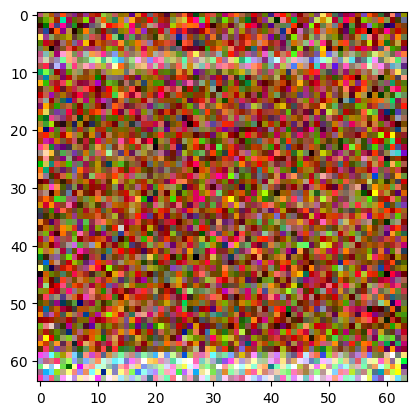

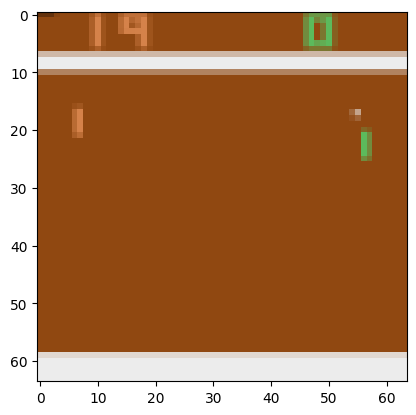